# EE P595 Homework 3: Identifying Malicious URLs (PyTorch)

<span style="color:red">**Released Date: February 5, 2026**</span>  
<span style="color:red">**Due Date: February 22, 2026**</span>

Build a 1D CNN to classify malicious HTTP request URLs using N-gram embeddings.

**Key Concepts:** N-gram extraction, Co-occurrence matrix, TruncatedSVD, 1D CNN

**Teammate:** _(Name if applicable)_

In [2]:
%pip install torch tqdm assertpy scikit-learn pandas matplotlib

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for assertpy: filename=assertpy-1.1-py3-none-any.whl size=42984 sha256=8b934ced380618b5bc16c031e41a11b6cdbbf0021020d34e56c708bb867579f4
  Stored in directory: /Users/samkorostov/Library/Caches/pip/wheels/ce/aa/b4/d759ec3ee7956d793b14eb5aff7632bafae8c3d58c82a3262d
Successfully built assertpy
Note: you may need to restart the kernel to use updated packages.


In [1]:
!tar -xf waf-urls.tar.xz

## 1. Data Loading

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# Load WAF URLs dataset
df = pd.read_csv('./waf-urls.csv')
print(f'Dataset: {len(df)} URLs')

# Split: 60% train, 20% val, 20% test
urls_tv, urls_test, labels_tv, labels_test = train_test_split(
    df['url'], df['label'], test_size=0.2, random_state=12345)
urls_train, urls_vali, labels_train, labels_vali = train_test_split(
    urls_tv, labels_tv, test_size=0.25, random_state=12345)

print(f'Train: {len(urls_train)}, Val: {len(urls_vali)}, Test: {len(urls_test)}')

Dataset: 60547 URLs
Train: 36327, Val: 12110, Test: 12110


## 2. N-Gram Functions

In [5]:
from assertpy import assert_that
from tqdm import tqdm

def iter_ngrams(text, n, start_symbol='\x00', end_symbol='\x01'):
    """Generate N-grams with start/end padding."""
    ## [ TODO 1 ] Implement N-gram generation
    # - Pad (n-1) start_symbols before text
    # - Pad n end_symbols after text
    # - Return generator of N-grams
    padded_text = start_symbol * (n - 1) + text + end_symbol * n
    for i in range(len(padded_text) - n + 1):
        yield padded_text[i:i+n]

# Test
assert_that(list(iter_ngrams('/test', n=3))).is_equal_to([
    '\x00\x00/', '\x00/t', '/te', 'tes', 'est', 'st\x01', 't\x01\x01', '\x01\x01\x01'
])

In [6]:
def build_ngram_mapping(urls, n, rare_threshold=2):
    """Build bidirectional N-gram to index mapping."""
    ngram_count = {}
    
    print('Counting N-grams...')
    for url in tqdm(urls):
        for ngram in iter_ngrams(url, n):
            ## [ TODO 2.1 ] Count N-gram occurrences
            ngram_count[ngram] = ngram_count.get(ngram, 0) + 1
    
    n2i, i2n = {}, []
    n_rare = 0
    
    print('Building mapping...')
    for ngram, count in tqdm(ngram_count.items()):
        ## [ TODO 2.2 ] Build mapping (only if count >= rare_threshold)
        # - Add to n2i and i2n if frequent
        # - Track n_rare for rare N-grams
        if count >= rare_threshold:
            n2i[ngram] = len(i2n)
            i2n.append(ngram)
        else:
            n_rare += 1
    
    print(f'Unique: {len(ngram_count)}, Kept: {len(i2n)}')
    return n2i, i2n

# Test
n2i_test, i2n_test = build_ngram_mapping(['/x', '/xyz/23', '/233'], n=3)
assert_that(len(n2i_test)).is_equal_to(5)

Counting N-grams...


100%|██████████| 3/3 [00:00<00:00, 10565.00it/s]


Building mapping...


100%|██████████| 15/15 [00:00<00:00, 253687.74it/s]

Unique: 15, Kept: 5


## 3. Co-occurrence Matrix

In [8]:
from scipy.sparse import dok_matrix

def build_cooccurrence_matrix(urls, n, n2i_mapping, window_size):
    """Build normalized co-occurrence matrix."""
    n_ngram = len(n2i_mapping)
    unknown_idx = n_ngram
    co_matrix = dok_matrix((n_ngram+1, n_ngram+1))
    
    print(f'Building co-occurrence...')
    for url in tqdm(urls):
        prev_indices = []
        for ngram in iter_ngrams(url, n):
            ## [ TODO 3.1 ] Get N-gram index (unknown_idx if not found)
            idx = n2i_mapping.get(ngram, unknown_idx)
            
            ## [ TODO 3.2 ] Update co-occurrence for prev neighbors in window
            for prev_idx in prev_indices[-window_size:]:
                co_matrix[idx, prev_idx] += 1
                co_matrix[prev_idx, idx] += 1
            
            prev_indices.append(idx)
    
    print('Normalizing...')
    row_sums = co_matrix.sum(axis=1)
    ## [ TODO 3.3 ] Normalize rows to probability distributions
    for (i, j) in tqdm(list(co_matrix.keys())):
        if row_sums[i, 0] > 0:
            co_matrix[i, j] /= row_sums[i, 0]
    
    return co_matrix

In [9]:
# Build N-gram mapping and co-occurrence matrix
N = 4
WINDOW_SIZE = 5

n2i_urls, i2n_urls = build_ngram_mapping(urls_train, N)
cooccurrence_urls = build_cooccurrence_matrix(urls_train, N, n2i_urls, WINDOW_SIZE)
print(f'Co-occurrence shape: {cooccurrence_urls.shape}')

Counting N-grams...


100%|██████████| 36327/36327 [00:00<00:00, 53747.86it/s]


Building mapping...


100%|██████████| 160195/160195 [00:00<00:00, 1640649.15it/s]


Unique: 160195, Kept: 82844
Building co-occurrence...


100%|██████████| 36327/36327 [06:09<00:00, 98.42it/s] 


Normalizing...


100%|██████████| 2542234/2542234 [00:42<00:00, 60391.05it/s]

Co-occurrence shape: (82845, 82845)


## 4. Embedding via TruncatedSVD

In [10]:
from sklearn.decomposition import TruncatedSVD

EMBEDDING_DIMS = 10

## [ TODO 4 ] Create TruncatedSVD and fit_transform co-occurrence matrix
# svd = TruncatedSVD(n_components=EMBEDDING_DIMS, n_iter=20, random_state=42)
# embedding_svd = svd.fit_transform(cooccurrence_urls)
embedding_svd = TruncatedSVD(n_components=EMBEDDING_DIMS, n_iter=20, random_state=42).fit_transform(cooccurrence_urls)

assert embedding_svd.shape == (len(n2i_urls)+1, EMBEDDING_DIMS)

## 5. PyTorch Model

In [12]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
print(f'Device: {device}')

Device: mps


In [13]:
def transform_urls(urls, padded_len, n, n2i_mapping, pad_symbol='\x01'):
    """Convert URLs to N-gram index sequences."""
    batch = np.empty((len(urls), padded_len + n), dtype=int)
    unknown_idx = len(n2i_mapping)
    
    for i, url in enumerate(urls):
        ## [ TODO 5.1 ] Pad URL to padded_len
        if len(url) < padded_len:
            url = url + pad_symbol * (padded_len - len(url))
        
        ## [ TODO 5.2 ] Convert N-grams to indices
        for j, ngram in enumerate(iter_ngrams(url, n)):
            batch[i, j] = n2i_mapping.get(ngram, unknown_idx)
    
    return batch

In [14]:
class URLDataset(Dataset):
    def __init__(self, urls, labels, padded_len, n, n2i_mapping):
        self.data = transform_urls(list(urls), padded_len, n, n2i_mapping)
        self.labels = labels.values.astype(np.float32)
    
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        return torch.tensor(self.data[idx], dtype=torch.long), torch.tensor(self.labels[idx])

In [16]:
class URLCNN(nn.Module):
    """1D CNN for URL classification."""
    def __init__(self, n_ngram, embedding_weights, dropout=0.25):
        super().__init__()
        embed_dim = embedding_weights.shape[1]
        
        ## [ TODO 6.1 ] Embedding layer (frozen, initialized with embedding_weights)
        self.embedding = nn.Embedding.from_pretrained(torch.tensor(embedding_weights, dtype=torch.float), freeze=True)
        
        ## [ TODO 6.2 ] Conv blocks
        # conv1: embed_dim -> 20, kernel=5, padding=2
        # conv2: 20 -> 40, kernel=5, padding=2
        # conv3: 40 -> 80, kernel=5, padding=2
        # pool1: MaxPool1d(2), pool2: MaxPool1d(5), pool3: MaxPool1d(5)
        self.conv1 = nn.Conv1d(embed_dim, 20, kernel_size=5, padding=2)
        self.conv2 = nn.Conv1d(20, 40, kernel_size=5, padding=2)
        self.conv3 = nn.Conv1d(40, 80, kernel_size=5, padding=2)
        self.pool1 = nn.MaxPool1d(2)
        self.pool2 = nn.MaxPool1d(5)
        self.pool3 = nn.MaxPool1d(5)
        
        ## [ TODO 6.3 ] FC layers
        # fc1: 160 -> 16, fc2: 16 -> 1
        self.fc1 = nn.Linear(80 * 2, 16) # Assuming input length is 8 (after pooling operations)
        self.fc2 = nn.Linear(16, 1)
        self.dropout = nn.Dropout(dropout)
    

    def forward(self, x):
        ## [ TODO 6.4 ] Forward pass
        # Embedding -> permute -> conv blocks -> flatten -> FC -> sigmoid
        x = self.embedding(x).permute(0, 2, 1)  # (batch, embed_dim, seq_len)
        x = self.pool1(torch.relu(self.conv1(x)))
        x = self.pool2(torch.relu(self.conv2(x)))
        x = self.pool3(torch.relu(self.conv3(x)))
        x = x.view(x.size(0), -1)  # Flatten
        x = self.dropout(torch.relu(self.fc1(x)))
        x = torch.sigmoid(self.fc2(x)).squeeze(1)
        return x

In [17]:
# Hyperparameters
BATCH_SIZE = 256
MAX_URL_LEN = 96
N_EPOCHS = 10

# Create datasets
train_dataset = URLDataset(urls_train, labels_train, MAX_URL_LEN, N, n2i_urls)
val_dataset = URLDataset(urls_vali, labels_vali, MAX_URL_LEN, N, n2i_urls)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)

model = URLCNN(len(n2i_urls), embedding_svd).to(device)
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters())

In [18]:
def train_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(y)
        correct += ((out > 0.5) == y).sum().item()
        total += len(y)
    return total_loss / total, correct / total

def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            total_loss += criterion(out, y).item() * len(y)
            correct += ((out > 0.5) == y).sum().item()
            total += len(y)
    return total_loss / total, correct / total

In [19]:
# Training loop
history = {'loss': [], 'acc': [], 'val_loss': [], 'val_acc': []}

for epoch in range(N_EPOCHS):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc = evaluate(model, val_loader, criterion)
    history['loss'].append(train_loss)
    history['acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    print(f'Epoch {epoch+1}: Train Acc={train_acc:.4f}, Val Acc={val_acc:.4f}')

torch.save(model.state_dict(), './model-url-cnn.pt')

Epoch 1: Train Acc=0.6444, Val Acc=0.8537
Epoch 2: Train Acc=0.8697, Val Acc=0.8984
Epoch 3: Train Acc=0.8985, Val Acc=0.9124
Epoch 4: Train Acc=0.9100, Val Acc=0.9195
Epoch 5: Train Acc=0.9156, Val Acc=0.9243
Epoch 6: Train Acc=0.9206, Val Acc=0.9273
Epoch 7: Train Acc=0.9241, Val Acc=0.9320
Epoch 8: Train Acc=0.9266, Val Acc=0.9304
Epoch 9: Train Acc=0.9333, Val Acc=0.9350
Epoch 10: Train Acc=0.9329, Val Acc=0.9387


## 6. Evaluation

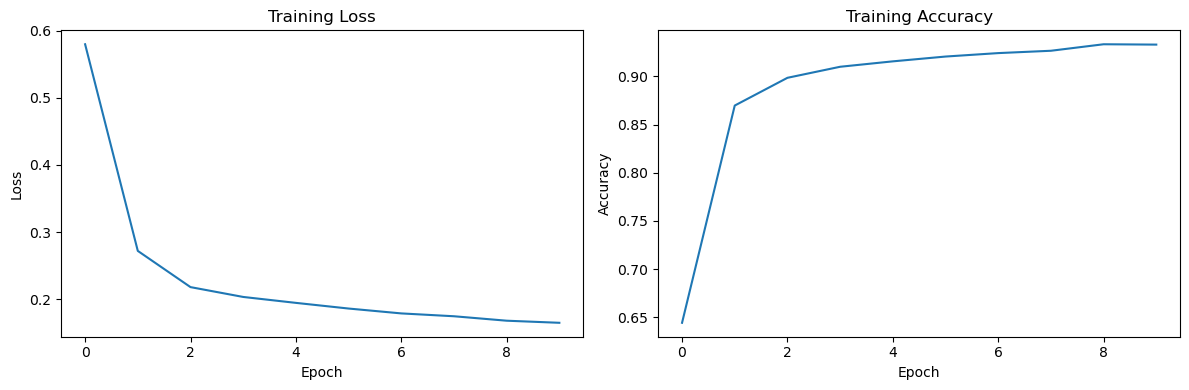

In [20]:
import matplotlib.pyplot as plt

## [ TODO 8 ] Plot loss and accuracy curves
loss = history['loss']
acc = history['acc']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(loss)
ax1.set_title('Training Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')

ax2.plot(acc)
ax2.set_title('Training Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')

plt.tight_layout()
plt.show()


In [21]:
from sklearn.metrics import confusion_matrix, classification_report

## [ TODO 9 ] Test evaluation
# - Create test dataset and loader
# - Predict and collect results
# - Print confusion matrix and classification report
test_dataset = URLDataset(urls_test, labels_test, MAX_URL_LEN, N, n2i_urls)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)
all_preds, all_labels = [], []
model.eval()
with torch.no_grad():
    for x, y in test_loader:
        x, y = x.to(device), y.to(device)
        out = model(x)
        all_preds.extend((out > 0.5).cpu().numpy())
        all_labels.extend(y.cpu().numpy())

print('Confusion Matrix:')
print(confusion_matrix(all_labels, all_preds))
print('Classification Report:')
print(classification_report(all_labels, all_preds))

Confusion Matrix:
[[6753  390]
 [ 389 4578]]
Classification Report:
              precision    recall  f1-score   support

         0.0       0.95      0.95      0.95      7143
         1.0       0.92      0.92      0.92      4967

    accuracy                           0.94     12110
   macro avg       0.93      0.93      0.93     12110
weighted avg       0.94      0.94      0.94     12110



## Questions

**Q1: Analyze model performance. Does lower loss indicate higher accuracy?** (2 pts)

**Your Answer:**
Based off the training loss and training accuracy plots, it does seem that yes, lower loss does indicate higher accuracy. In the plots you can see that as loss decreases, accuracy increases pretty much at the same rate.

**Q2: Is large window_size (e.g., 50) good? Other compression methods?** (2 pts)

**Your Answer:**
For URLs, since they are short and highly structured (ex. http://, ip addresses, .com/other domains, etc), 
a large window size is not that good. 

Due to the highly structured nature of URL's most meaningful ngram relationships are local patterns, 
and a window of a size as large as 50 would capture co-occurences across almost the entire URL, adding noise
from unrelated ngrams.

Another compression nature that could work here is TF-IDF.



## Submission
Submit: `homework-3-student-20260205.ipynb` + `model-url-cnn.pt`